# Inferenzstatistik & maschinelles Lernen
**So benutzt du dieses Notebook in Colab**
1. Lade die beiden CSV-Dateien in Colab hoch (links auf das Ordner-Symbol klicken
   und die Dateien per Drag&Drop ablegen). Sie liegen dann unter `/content/`.
2. Notebook ausführen: Zellen der Reihe nach mit `Shift+Enter`.

Die Dateien werden direkt über ihren Pfad geladen:
`/content/pisa_test_scores.csv` und `/content/WA_Fn-UseC_-HR-Employee-Attrition.csv`.



## 0 · Setup – Bibliotheken importieren

In [ ]:
# In Colab sind alle Pakete vorinstalliert. Falls lokal: pip install ...
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)
print('Setup fertig.')

Setup fertig.


In [ ]:
# Feste Pfade in Colab. Die Dateien muessen vorher in Colab hochgeladen worden sein
# (Ordner-Symbol links -> Dateien hineinziehen). Sie liegen dann unter /content/.
PFAD_PISA = '/content/pisa_test_scores.csv'
PFAD_HR   = '/content/WA_Fn-UseC_-HR-Employee-Attrition.csv'

---
# Aufgabe 1 · Binomialverteilung & Satz von Bayes

**Sachverhalt:** Eine Münze wird **250 Mal** geworfen → **140 Kopf**, **110 Zahl**.
Aussage: *„Wäre die Münze unvoreingenommen, läge die Chance auf ein so extremes
Ergebnis bei weniger als 7 %.“*

**Frage:** Sind die Daten ein Beweis dafür, dass die Münze verzerrt ist?

Vorgehen in zwei Schritten:
1. **Binomialverteilung** → woher kommen die 7 %?
2. **Satz von Bayes** → Wahrscheinlichkeit, dass die Münze Kopf zeigt.


### Was ist eine Binomialverteilung? (für das Word-Dokument)
Die Binomialverteilung beschreibt, wie wahrscheinlich es ist, bei **n unabhängigen
Wiederholungen** eines Zufallsexperiments mit nur **zwei Ausgängen** (Erfolg/Misserfolg,
hier Kopf/Zahl) und konstanter Erfolgswahrscheinlichkeit *p* genau *k* Erfolge zu erhalten:

$$P(X=k)=\binom{n}{k}\,p^{k}\,(1-p)^{\,n-k}$$

Sie entsteht als Summe von *n* unabhängigen **Bernoulli-Experimenten** (ein einzelner Wurf).
Erwartungswert $E[X]=n\cdot p$, Varianz $Var[X]=n\cdot p\cdot(1-p)$.


In [ ]:
# ---------- Schritt 1: Binomialverteilung – woher kommen die 7 %? ----------
n  = 250     # Anzahl Würfe
k  = 140     # beobachtete Anzahl Kopf
p0 = 0.5     # Nullhypothese H0: faire Münze

# Kennzahlen unter H0
mu    = n * p0
sigma = np.sqrt(n * p0 * (1 - p0))
print(f'Erwartungswert unter H0 : {mu:.1f}')
print(f'Standardabweichung      : {sigma:.4f}')
print(f'Beobachtet              : {k}  (das sind {(k-mu)/sigma:.2f} Standardabw. über dem Mittel)')

# Einseitiger p-Wert: P(X >= 140) = Wahrscheinlichkeit für >= 140 Kopf
# stats.binom.sf(k-1, n, p0) liefert P(X >= k)
p_einseitig = stats.binom.sf(k - 1, n, p0)
print(f'\nEinseitiger p-Wert  P(X>=140)           : {p_einseitig:.4f}  = {p_einseitig*100:.2f} %')

# Zweiseitiger p-Wert (exakter Binomialtest): "so extrem" in BEIDE Richtungen,
# d.h. >= 140 Kopf ODER <= 110 Kopf (symmetrisch um den Erwartungswert 125)
test = stats.binomtest(k, n, p0, alternative='two-sided')
print(f'Zweiseitiger p-Wert P(X>=140 oder X<=110): {test.pvalue:.4f}  = {test.pvalue*100:.2f} %')

Erwartungswert unter H0 : 125.0
Standardabweichung      : 7.9057
Beobachtet              : 140  (das sind 1.90 Standardabw. über dem Mittel)

Einseitiger p-Wert  P(X>=140)           : 0.0332  = 3.32 %
Zweiseitiger p-Wert P(X>=140 oder X<=110): 0.0664  = 6.64 %


**Interpretation Schritt 1.** Die genannten „weniger als 7 %“ sind der **zweiseitige
p-Wert ≈ 6,64 %**: Wäre die Münze fair, läge die Wahrscheinlichkeit, ein so extremes oder
extremeres Ergebnis (≥ 140 Kopf **oder** ≤ 110 Kopf) zu sehen, bei nur ca. 6,6 %.

Bei einem üblichen Signifikanzniveau von **α = 5 %** ist 6,64 % **größer** als 5 %.
Das Ergebnis ist also auffällig, aber **nicht** signifikant – kein „Beweis“ für eine
verzerrte Münze, nur ein verdächtiger Hinweis.


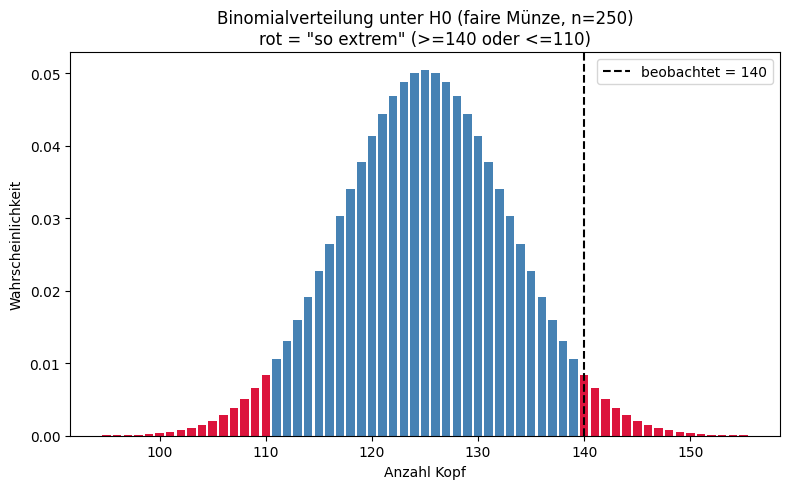

In [ ]:
# Visualisierung der Binomialverteilung unter H0 mit markiertem Ablehnungsbereich
x = np.arange(95, 156)
pmf = stats.binom.pmf(x, n, p0)
farben = ['crimson' if (xi >= 140 or xi <= 110) else 'steelblue' for xi in x]

plt.bar(x, pmf, color=farben)
plt.axvline(k, color='black', linestyle='--', label='beobachtet = 140')
plt.title('Binomialverteilung unter H0 (faire Münze, n=250)\nrot = "so extrem" (>=140 oder <=110)')
plt.xlabel('Anzahl Kopf'); plt.ylabel('Wahrscheinlichkeit')
plt.legend(); plt.tight_layout(); plt.show()

### Was ist der Satz von Bayes? (für das Word-Dokument)
Der Satz von Bayes verknüpft bedingte Wahrscheinlichkeiten und erlaubt, eine
**Vorannahme (Prior)** anhand von **beobachteten Daten (Likelihood)** zu einer
**aktualisierten Überzeugung (Posterior)** zu machen:

$$P(\theta\mid D)=\frac{P(D\mid\theta)\,P(\theta)}{P(D)}$$

Er wird überall dort eingesetzt, wo man aus Daten auf einen unbekannten Parameter
schließen will (Spamfilter, medizinische Diagnostik, A/B-Tests …). Hier schätzen wir
den unbekannten Parameter *p* = Wahrscheinlichkeit für **Kopf**.


In [ ]:
# ---------- Schritt 2: Bayes – Wahrscheinlichkeit, dass die Münze Kopf zeigt ----------
# Konjugierter Ansatz: Beta-Prior + Binomial-Likelihood -> Beta-Posterior.
# Uninformativer (objektiver) Prior Beta(1,1) = Gleichverteilung: wir nehmen vorab
# keine Richtung an. Nach Beobachtung von k Kopf und (n-k) Zahl gilt:
#   Posterior = Beta(alpha_prior + k , beta_prior + (n-k))
alpha_prior, beta_prior = 1, 1
alpha_post = alpha_prior + k            # 1 + 140 = 141
beta_post  = beta_prior  + (n - k)      # 1 + 110 = 111

# Punktschätzung: Posterior-Erwartungswert = bayesianische Schätzung für P(Kopf)
p_bayes = alpha_post / (alpha_post + beta_post)
print(f'Bayes-Schätzung  P(Kopf) = {p_bayes:.4f}   (klassisch: {k}/{n} = {k/n:.4f})')

# 95%-Glaubwürdigkeitsintervall (credible interval)
ci_low, ci_high = stats.beta.ppf([0.025, 0.975], alpha_post, beta_post)
print(f'95% Credible Interval    = [{ci_low:.4f}, {ci_high:.4f}]')

# Posterior-Wahrscheinlichkeit, dass die Münze KOPF-lastig ist (p > 0.5)
p_verzerrt = 1 - stats.beta.cdf(0.5, alpha_post, beta_post)
print(f'P(p > 0.5 | Daten)       = {p_verzerrt:.4f}  ->  {p_verzerrt*100:.1f} %')

Bayes-Schätzung  P(Kopf) = 0.5595   (klassisch: 140/250 = 0.5600)
95% Credible Interval    = [0.4980, 0.6202]
P(p > 0.5 | Daten)       = 0.9710  ->  97.1 %


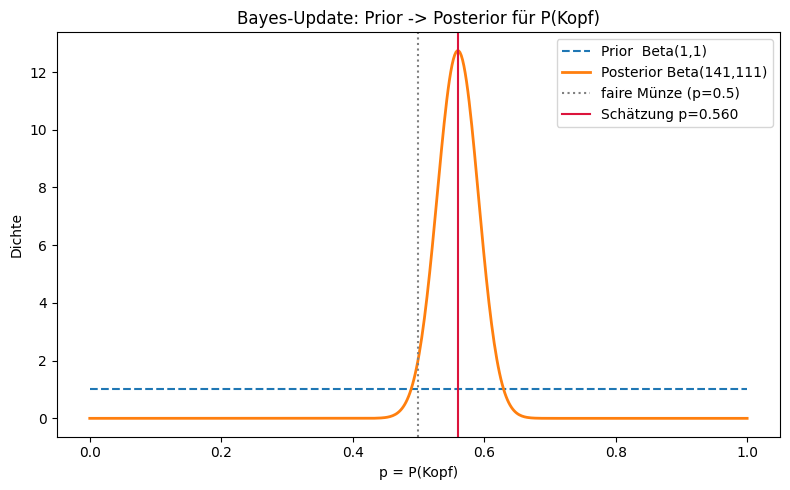

In [ ]:
# Prior und Posterior gemeinsam plotten
xx = np.linspace(0, 1, 500)
plt.plot(xx, stats.beta.pdf(xx, alpha_prior, beta_prior), label='Prior  Beta(1,1)', linestyle='--')
plt.plot(xx, stats.beta.pdf(xx, alpha_post, beta_post),  label=f'Posterior Beta({alpha_post},{beta_post})', linewidth=2)
plt.axvline(0.5, color='gray', linestyle=':', label='faire Münze (p=0.5)')
plt.axvline(p_bayes, color='crimson', linestyle='-', label=f'Schätzung p={p_bayes:.3f}')
plt.title('Bayes-Update: Prior -> Posterior für P(Kopf)')
plt.xlabel('p = P(Kopf)'); plt.ylabel('Dichte')
plt.legend(); plt.tight_layout(); plt.show()

### Fazit Aufgabe 1
* **Binomial / Frequentistisch:** Der zweiseitige p-Wert beträgt **≈ 6,64 %** (> 5 %).
  Das Ergebnis ist verdächtig, aber bei α = 5 % **statistisch nicht signifikant** –
  also **kein strenger Beweis** für eine verzerrte Münze.
* **Bayes:** Die beste Schätzung für P(Kopf) ist **≈ 0,56**; das 95 %-Glaubwürdigkeits­intervall
  **[0,498 ; 0,620]** schließt 0,5 *gerade noch* ein. Die Wahrscheinlichkeit, dass die
  Münze tatsächlich kopflastig ist (p > 0,5), liegt bei **≈ 97 %**.

**Gesamtaussage:** Die Daten deuten klar auf eine leichte Kopf-Verzerrung hin, liefern
aber keinen endgültigen „Beweis“. Mehr Würfe würden für Klarheit sorgen.


---
# Aufgabe 2 · PISA-Testergebnisse & Internet-Infrastruktur

Datensatz **`pisa_test_score.csv`** (Quelle: Weltbank). Wir untersuchen:
* **a)** Konfidenzintervalle für die typische Punktzahl in Lesen, Naturwissenschaft, Mathematik
* **b)** Hypothesentest: Führt Internet-Infrastruktur zu höheren Testergebnissen?
* **c)** Lineares Modell zur Vorhersage der Mathematik-Punktzahl


In [ ]:
# Datensatz über festen Pfad laden
pisa = pd.read_csv(PFAD_PISA)
print('Form (Zeilen, Spalten):', pisa.shape)
print('\nSpalten:', pisa.columns.tolist())
pisa.head()

Form (Zeilen, Spalten): (70, 5)

Spalten: ['Country Code', 'internet_users_per_100', 'Math', 'Reading', 'Science']


,Country Code,internet_users_per_100,Math,Reading,Science
0,ALB,63.252933,413.1570,405.2588,427.2250
1,ARE,90.500000,427.4827,433.5423,436.7311
2,ARG,68.043064,409.0333,425.3031,432.2262
3,AUS,84.560519,493.8962,502.9006,509.9939
4,AUT,83.940142,496.7423,484.8656,495.0375


> **Spaltennamen deines Datensatzes** (bereits eingetragen): `Country Code`,
> `internet_users_per_100`, `Math`, `Reading`, `Science`.
> Es gibt kein Fach *Schreiben* – nur Lesen, Naturwissenschaft, Mathematik.


In [ ]:
# ---------- Spalten setzen (auf deinen Datensatz abgestimmt) ----------
COL_READING  = 'Reading'
COL_SCIENCE  = 'Science'
COL_MATH     = 'Math'
COL_INTERNET = 'internet_users_per_100'   # Internet-Nutzer je 100 Einwohner

# Sicherheitscheck: existieren die Spalten wirklich?
for sp in [COL_READING, COL_SCIENCE, COL_MATH, COL_INTERNET]:
    assert sp in pisa.columns, f'Spalte {sp!r} nicht gefunden! Verfuegbar: {pisa.columns.tolist()}'
print('Lesen      ->', COL_READING)
print('Naturwiss. ->', COL_SCIENCE)
print('Mathematik ->', COL_MATH)
print('Internet   ->', COL_INTERNET)

Lesen      -> Reading
Naturwiss. -> Science
Mathematik -> Math
Internet   -> internet_users_per_100


### a) Konfidenzintervalle für die typische Punktzahl

In [ ]:
# Ein Konfidenzintervall (KI) gibt den Bereich an, in dem der WAHRE Mittelwert
# mit z.B. 95% Sicherheit liegt. Da sigma unbekannt ist und n endlich, nutzen wir die t-Verteilung.
def konfidenzintervall(daten, konfidenz=0.95):
    daten = pd.Series(daten).dropna()
    n   = len(daten)
    m   = daten.mean()
    se  = stats.sem(daten)                              # Standardfehler des Mittels
    h   = se * stats.t.ppf((1 + konfidenz) / 2, n - 1)  # Fehlermarge
    return n, m, m - h, m + h

print('95%-Konfidenzintervalle der mittleren Punktzahl:\n')
for name, sp in [('Lesen', COL_READING), ('Naturwissenschaft', COL_SCIENCE), ('Mathematik', COL_MATH)]:
    n_, m_, lo_, hi_ = konfidenzintervall(pisa[sp])
    print(f'{name:18s}: Mittelwert = {m_:6.1f}   95%-KI = [{lo_:6.1f}, {hi_:6.1f}]   (n={n_})')

95%-Konfidenzintervalle der mittleren Punktzahl:

Lesen             : Mittelwert =  461.0   95%-KI = [ 449.2,  472.8]   (n=70)
Naturwissenschaft : Mittelwert =  465.4   95%-KI = [ 453.9,  477.0]   (n=70)
Mathematik        : Mittelwert =  461.0   95%-KI = [ 448.3,  473.7]   (n=70)


### b) Hypothesentest: Höhere Internet-Verbreitung → höhere Punktzahl?

**Hypothesen** (einseitig):
* H0: Internet-Verbreitung hat **keinen positiven** Einfluss auf die Punktzahl.
* H1: Mehr Internet-Verbreitung geht mit **höherer** Punktzahl einher.

Wir prüfen das auf zwei Wegen: (1) **Korrelationstest** und (2) **Gruppenvergleich**
(Länder mit über- vs. unter­durchschnittlicher Internet-Verbreitung).


In [ ]:
# Durchschnittliche PISA-Punktzahl je Land über alle drei Fächer
pisa['avg_score'] = pisa[[COL_READING, COL_SCIENCE, COL_MATH]].mean(axis=1)

# --- Methode 1: Pearson-Korrelation Internet <-> Durchschnittspunktzahl ---
d = pisa[[COL_INTERNET, 'avg_score']].dropna()
r, p_zwei = stats.pearsonr(d[COL_INTERNET], d['avg_score'])
p_eins = p_zwei / 2 if r > 0 else 1 - p_zwei / 2   # einseitig (H1: positiver Zusammenhang)
print('METHODE 1 – Korrelationstest')
print(f'  Korrelationskoeffizient r = {r:.3f}')
print(f'  einseitiger p-Wert        = {p_eins:.4f}')

# --- Methode 2: Median-Split + t-Test (Welch) ---
median_int = d[COL_INTERNET].median()
hoch    = pisa.loc[pisa[COL_INTERNET] >= median_int, 'avg_score'].dropna()
niedrig = pisa.loc[pisa[COL_INTERNET] <  median_int, 'avg_score'].dropna()
t_stat, p_t = stats.ttest_ind(hoch, niedrig, equal_var=False)
print('\nMETHODE 2 – t-Test: hohe vs. niedrige Internet-Verbreitung')
print(f'  Mittel (hoch)    = {hoch.mean():.1f}')
print(f'  Mittel (niedrig) = {niedrig.mean():.1f}')
print(f'  t = {t_stat:.3f},  einseitiger p-Wert = {p_t/2:.4f}')

alpha = 0.05
print('\nErgebnis:', 'H0 wird abgelehnt -> signifikant positiver Effekt.'
      if p_eins < alpha else 'H0 wird NICHT abgelehnt.')

METHODE 1 – Korrelationstest
  Korrelationskoeffizient r = 0.636
  einseitiger p-Wert        = 0.0000

METHODE 2 – t-Test: hohe vs. niedrige Internet-Verbreitung
  Mittel (hoch)    = 494.3
  Mittel (niedrig) = 430.6
  t = 6.953,  einseitiger p-Wert = 0.0000

Ergebnis: H0 wird abgelehnt -> signifikant positiver Effekt.


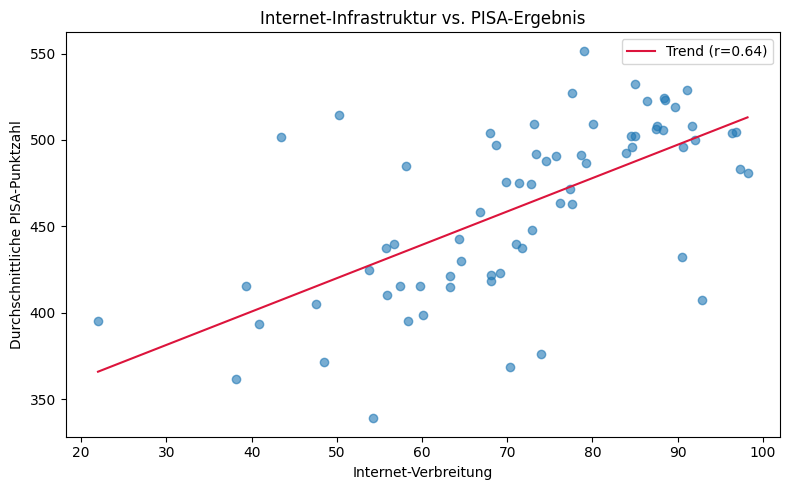

In [ ]:
# Streudiagramm mit Regressionsgerade zur Veranschaulichung
import numpy as np
plt.scatter(d[COL_INTERNET], d['avg_score'], alpha=0.6)
b, a = np.polyfit(d[COL_INTERNET], d['avg_score'], 1)
xs = np.linspace(d[COL_INTERNET].min(), d[COL_INTERNET].max(), 100)
plt.plot(xs, a + b*xs, color='crimson', label=f'Trend (r={r:.2f})')
plt.xlabel('Internet-Verbreitung'); plt.ylabel('Durchschnittliche PISA-Punktzahl')
plt.title('Internet-Infrastruktur vs. PISA-Ergebnis')
plt.legend(); plt.tight_layout(); plt.show()

### c) Lineares Modell zur Vorhersage von Mathematik

> **Hinweis:** Die Aufgabe nennt „Lesen und Schreiben“. PISA misst aber **Lesen,
> Naturwissenschaft und Mathematik** – ein eigenes Fach *Schreiben* gibt es nicht.
> Wir verwenden daher **Lesen + Naturwissenschaft** als Prädiktoren für Mathematik.
> Falls dein Datensatz andere Spalten hat, oben im Config-Block anpassen.


In [ ]:
import statsmodels.api as sm

dlm = pisa[[COL_READING, COL_SCIENCE, COL_MATH]].dropna()
X = sm.add_constant(dlm[[COL_READING, COL_SCIENCE]])   # Prädiktoren + Achsenabschnitt
y = dlm[COL_MATH]                                       # Zielgröße

modell = sm.OLS(y, X).fit()
print(modell.summary())

                            OLS Regression Results                            
Dep. Variable:                   Math   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     637.4
Date:                Thu, 28 May 2026   Prob (F-statistic):           2.49e-44
Time:                        09:34:33   Log-Likelihood:                -272.28
No. Observations:                  70   AIC:                             550.6
Df Residuals:                      67   BIC:                             557.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -38.9955     14.078     -2.770      0.0

R²        = 0.950  (Anteil erklärter Varianz)
R² (adj.) = 0.949


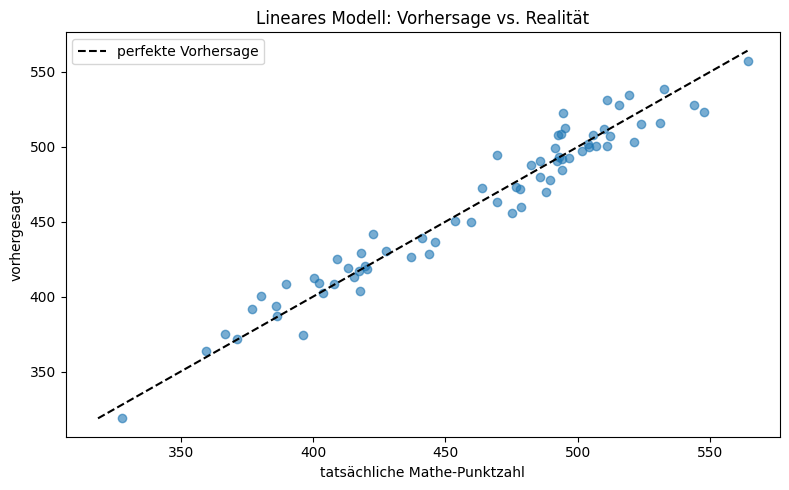

In [ ]:
# Modellgüte kompakt + Vorhersage vs. tatsächlich
print(f'R²        = {modell.rsquared:.3f}  (Anteil erklärter Varianz)')
print(f'R² (adj.) = {modell.rsquared_adj:.3f}')

y_hat = modell.predict(X)
plt.scatter(y, y_hat, alpha=0.6)
lims = [min(y.min(), y_hat.min()), max(y.max(), y_hat.max())]
plt.plot(lims, lims, 'k--', label='perfekte Vorhersage')
plt.xlabel('tatsächliche Mathe-Punktzahl'); plt.ylabel('vorhergesagt')
plt.title('Lineares Modell: Vorhersage vs. Realität')
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation c).** Das Modell hat die Form
`Mathe = const + b1·Lesen + b2·Naturwissenschaft`. Das **R²** zeigt, wie viel der
Streuung der Mathe-Punktzahl durch Lesen und Naturwissenschaft erklärt wird. Die
**p-Werte** der Koeffizienten (Spalte `P>|t|`) zeigen, welche Prädiktoren signifikant
sind. Da Fächerleistungen stark korrelieren, ist meist ein hohes R² zu erwarten.


---
# Aufgabe 5 · IBM HR Attrition – Klassifikation mit Entscheidungsbäumen

Ziel: Vorhersagen, ob ein Mitarbeiter das Unternehmen verlässt (`Attrition`).
Datensatz: **`WA_Fn-UseC_-HR-Employee-Attrition.csv`**.


In [ ]:
hr = pd.read_csv(PFAD_HR)
print('Form:', hr.shape)
hr.head()

Form: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### a) Datenaufbereitung

In [ ]:
# 1) Fehlende Werte prüfen
fehlend = hr.isnull().sum()
print('Anzahl fehlender Werte gesamt:', fehlend.sum())
print(fehlend[fehlend > 0] if fehlend.sum() else '-> keine fehlenden Werte.')
# Hinweis: Der IBM-Datensatz ist vollständig. Gäbe es fehlende Werte, würde man je nach
# Variable löschen (bei wenigen Fällen) oder imputieren (z.B. Median/Modus).

Anzahl fehlender Werte gesamt: 0
-> keine fehlenden Werte.


In [ ]:
# 2) Nutzlose Spalten entfernen: konstante Spalten + ID-Spalte
konstante = [c for c in hr.columns if hr[c].nunique() <= 1]   # z.B. EmployeeCount, StandardHours, Over18
print('Konstante Spalten (werden entfernt):', konstante)
zu_entfernen = konstante + (['EmployeeNumber'] if 'EmployeeNumber' in hr.columns else [])
hr = hr.drop(columns=zu_entfernen)

# 3) Zielvariable in 0/1 kodieren
hr['Attrition'] = hr['Attrition'].map({'Yes': 1, 'No': 0})
print('\nKlassenverteilung Attrition (1 = verlässt das Unternehmen):')
print(hr['Attrition'].value_counts(normalize=True).round(3))

Konstante Spalten (werden entfernt): ['EmployeeCount', 'Over18', 'StandardHours']

Klassenverteilung Attrition (1 = verlässt das Unternehmen):
Attrition
0    0.839
1    0.161
Name: proportion, dtype: float64


In [ ]:
# 4) Kategorielle Variablen per One-Hot-Encoding in Zahlen umwandeln
kategorisch = hr.select_dtypes(include='object').columns.tolist()
print('Kategorielle Spalten:', kategorisch)
hr_enc = pd.get_dummies(hr, columns=kategorisch, drop_first=True)
print('Form nach Encoding:', hr_enc.shape)

Kategorielle Spalten: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Form nach Encoding: (1470, 45)


**Anmerkung zur Klassenverteilung:** Nur ca. **16 %** der Mitarbeiter verlassen das
Unternehmen → die Klassen sind **unausgewogen**. Das ist für Wahl von Algorithmus und
Bewertungsmetrik (siehe d) entscheidend.


### b) Feature-Extraktion

Top 15 wichtigste Features:
MonthlyIncome              0.0738
OverTime_Yes               0.0568
Age                        0.0557
DailyRate                  0.0533
TotalWorkingYears          0.0501
MonthlyRate                0.0462
YearsAtCompany             0.0461
HourlyRate                 0.0438
DistanceFromHome           0.0421
StockOptionLevel           0.0360
YearsWithCurrManager       0.0357
PercentSalaryHike          0.0334
NumCompaniesWorked         0.0319
EnvironmentSatisfaction    0.0296
YearsInCurrentRole         0.0292
dtype: float64


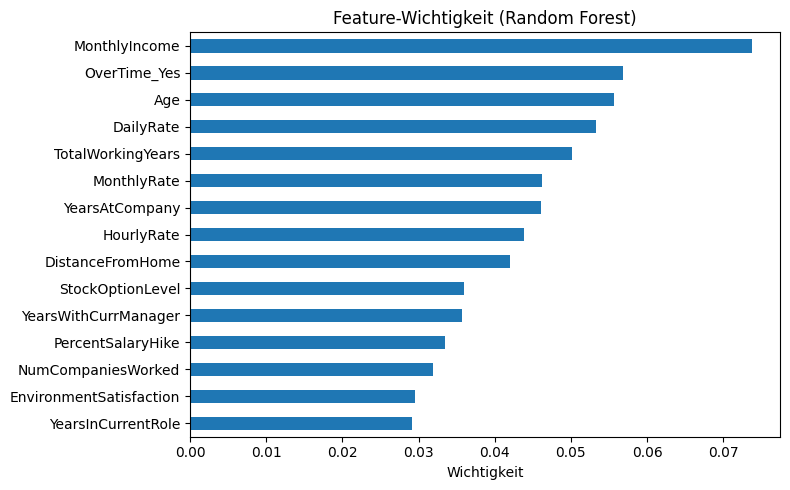

In [ ]:
# Wir nutzen die FEATURE-WICHTIGKEIT eines Random Forest als Auswahl-Metrik.
# Begründung: baumbasierte Wichtigkeit erfasst auch nichtlineare Zusammenhänge und
# Wechselwirkungen, anders als eine reine lineare Korrelation.
from sklearn.ensemble import RandomForestClassifier

X = hr_enc.drop(columns='Attrition')
y = hr_enc['Attrition']

rf_fs = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf_fs.fit(X, y)

wichtigkeit = pd.Series(rf_fs.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Top 15 wichtigste Features:')
print(wichtigkeit.head(15).round(4))

# Plot
wichtigkeit.head(15).iloc[::-1].plot(kind='barh')
plt.title('Feature-Wichtigkeit (Random Forest)')
plt.xlabel('Wichtigkeit'); plt.tight_layout(); plt.show()

In [ ]:
# Die wichtigsten Features auswählen (hier Top 15)
top_features = wichtigkeit.head(15).index.tolist()
X_sel = X[top_features]
print('Ausgewählte Features:', top_features)

Ausgewählte Features: ['MonthlyIncome', 'OverTime_Yes', 'Age', 'DailyRate', 'TotalWorkingYears', 'MonthlyRate', 'YearsAtCompany', 'HourlyRate', 'DistanceFromHome', 'StockOptionLevel', 'YearsWithCurrManager', 'PercentSalaryHike', 'NumCompaniesWorked', 'EnvironmentSatisfaction', 'YearsInCurrentRole']


### c) Entscheidungsbaum-Modell

In [ ]:
from sklearn.model_selection import train_test_split

# Trainings-/Testaufteilung 75/25, stratifiziert (Klassenverhältnis bleibt erhalten)
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.25, stratify=y, random_state=42)
print('Training:', X_train.shape, ' Test:', X_test.shape)

Training: (1102, 15)  Test: (368, 15)


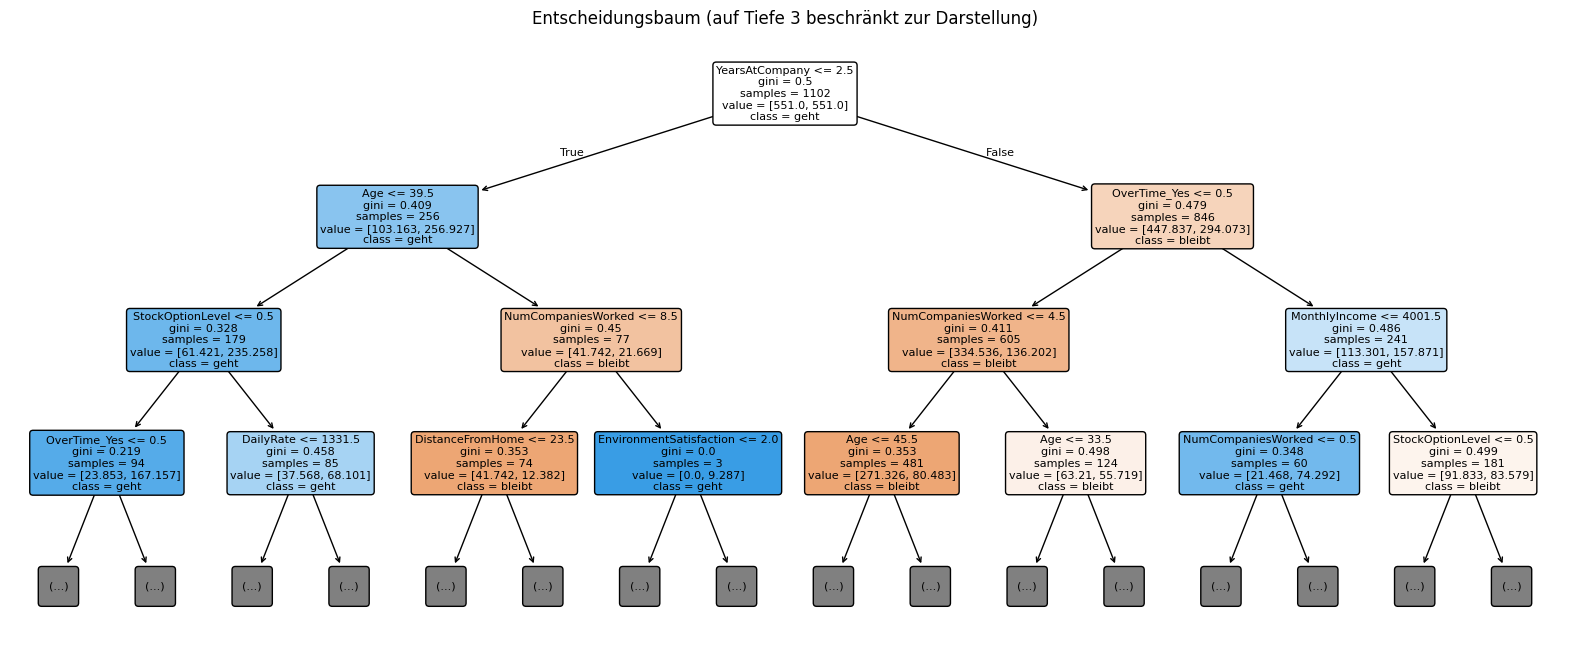

In [ ]:
# (i) Einzelner Entscheidungsbaum – gut interpretierbar, dient als Baseline
from sklearn.tree import DecisionTreeClassifier, plot_tree

baum = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
baum.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(baum, feature_names=X_sel.columns, class_names=['bleibt', 'geht'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Entscheidungsbaum (auf Tiefe 3 beschränkt zur Darstellung)')
plt.show()

In [ ]:
# (ii) Random Forest – das gewählte Hauptmodell
# Warum Random Forest? Ein einzelner Baum überanpasst (overfitting) leicht. Random Forest
# kombiniert viele Bäume (Bagging) -> geringere Varianz, stabilere und meist genauere
# Vorhersagen. 'class_weight=balanced' fängt das Klassenungleichgewicht ab.
from sklearn.ensemble import RandomForestClassifier

modell = RandomForestClassifier(
    n_estimators=400, max_depth=None, class_weight='balanced',
    random_state=42, n_jobs=-1)
modell.fit(X_train, y_train)
print('Random Forest trainiert.')

Random Forest trainiert.


### d) Evaluierung

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)

y_pred  = modell.predict(X_test)
y_proba = modell.predict_proba(X_test)[:, 1]

print('=== Klassifikationsbericht ===')
print(classification_report(y_test, y_pred, target_names=['bleibt (0)', 'geht (1)']))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba), 3))

=== Klassifikationsbericht ===
              precision    recall  f1-score   support

  bleibt (0)       0.85      0.97      0.90       309
    geht (1)       0.33      0.08      0.14        59

    accuracy                           0.83       368
   macro avg       0.59      0.53      0.52       368
weighted avg       0.76      0.83      0.78       368

ROC-AUC: 0.739


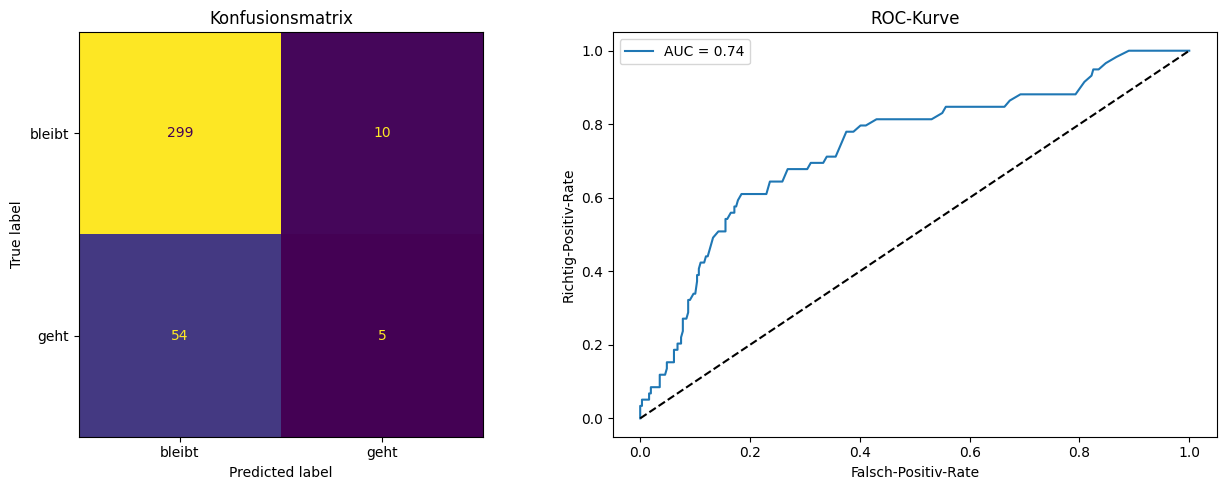

In [ ]:
# Konfusionsmatrix
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['bleibt', 'geht']).plot(ax=ax[0], colorbar=False)
ax[0].set_title('Konfusionsmatrix')

# ROC-Kurve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.2f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('Falsch-Positiv-Rate'); ax[1].set_ylabel('Richtig-Positiv-Rate')
ax[1].set_title('ROC-Kurve'); ax[1].legend()
plt.tight_layout(); plt.show()

**Demonstration einer Verbesserung – Schwellenwert senken.** Beim Standard-Schwellenwert
0,5 erkennt das Modell zu wenige Kündiger (niedriger Recall). Da uns das *Finden* gefährdeter
Mitarbeiter wichtiger ist als gelegentliche Fehlalarme, senken wir die Entscheidungs­schwelle.


In [ ]:
# Schwellenwert von 0.5 auf 0.30 senken: mehr Kuendiger werden erkannt (Recall steigt),
# dafuer sinkt die Precision (mehr Fehlalarme) - der klassische Trade-off.
schwelle = 0.30
y_pred_neu = (y_proba >= schwelle).astype(int)
print(f'Klassifikationsbericht bei Schwellenwert = {schwelle}')
print(classification_report(y_test, y_pred_neu, target_names=['bleibt (0)', 'geht (1)']))

Klassifikationsbericht bei Schwellenwert = 0.3
              precision    recall  f1-score   support

  bleibt (0)       0.87      0.92      0.89       309
    geht (1)       0.38      0.27      0.32        59

    accuracy                           0.81       368
   macro avg       0.62      0.59      0.60       368
weighted avg       0.79      0.81      0.80       368



### Begründung der Metriken & Verbesserungsmöglichkeiten

**Warum nicht nur Accuracy?** Da nur ~16 % kündigen, erreicht ein Modell, das *immer*
„bleibt“ vorhersagt, schon ~84 % Accuracy – ohne einen einzigen Kündiger zu erkennen.
Accuracy ist daher irreführend. Aussagekräftiger sind:
* **Recall (Kündiger):** Anteil der tatsächlichen Kündiger, die erkannt werden – im
  HR-Kontext besonders wichtig, weil man gefährdete Mitarbeiter finden will.
* **Precision (Kündiger):** Anteil der vorhergesagten Kündiger, die wirklich kündigen.
* **F1-Score:** harmonisches Mittel aus Precision und Recall.
* **ROC-AUC:** schwellenunabhängige Gesamtgüte der Trennfähigkeit.

**Mögliche Verbesserungen (nicht umzusetzen, nur zu erläutern):**
1. **Klassenungleichgewicht** gezielter behandeln: Oversampling der Minderheit (SMOTE),
   Undersampling oder kostensensitives Lernen.
2. **Schwellenwert-Tuning:** Standard 0,5 senken, um den Recall für Kündiger zu erhöhen.
3. **Hyperparameter-Optimierung** per `GridSearchCV`/`RandomizedSearchCV` mit
   **k-facher Kreuzvalidierung** statt nur einem Train/Test-Split.
4. **Boosting-Verfahren** (XGBoost, Gradient Boosting, AdaBoost) testen – oft etwas genauer.
5. **Feature-Engineering:** neue Merkmale bilden, weniger wichtige entfernen.
